In [1]:
#작업준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

In [4]:
#데이터 수집
df=pd.read_csv('fish.csv')
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [9]:
#데이터 전처리(EDA)
X=df.drop(['Species'],axis=1)[['Weight','Length']]
y=df['Species']

In [14]:
np_X=X.to_numpy()
x_y1,x_y2=np_X[y=='Smelt'],np_X[y=='Bream']

In [28]:
new_X=np_X[(y=='Smelt')|(y=='Bream')]

In [33]:
new_y=y[(y=='Smelt')|(y=='Bream')]
np.where(new_y=='Smelt',0,1)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

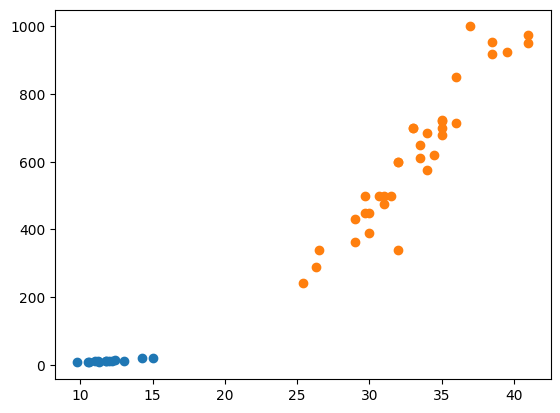

In [15]:
import matplotlib.pyplot as plt
plt.scatter(x_y1[:,1],x_y1[:,0])
plt.scatter(x_y2[:,1],x_y2[:,0])
plt.show()

In [35]:
#모델 선정 
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
m=KNeighborsClassifier(3)
m.fit(new_X,new_y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
# 예측 및 검정
m.predict(new_X)

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

In [40]:
new_X.shape

(49, 2)

In [45]:
m.classes_

array(['Bream', 'Smelt'], dtype=object)

In [46]:
m.predict(new_X[:35])

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [51]:
m.predict([[150,30]])

array(['Smelt'], dtype=object)

In [54]:
d,idx=m.kneighbors([[150,30]])

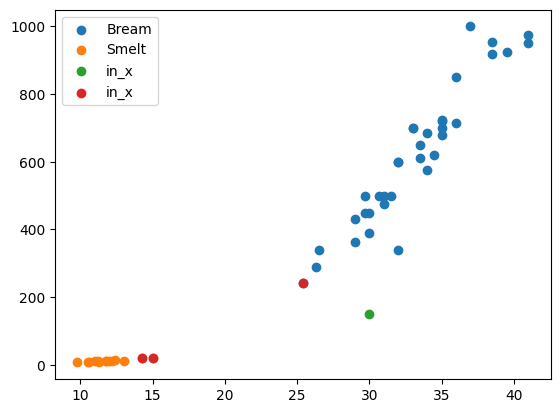

In [55]:
plt.scatter(new_X[:35,1],new_X[:35,0],label='Bream')
plt.scatter(new_X[35:,1],new_X[35:,0],label='Smelt')
plt.scatter(30,150,label='in_x')
plt.scatter(new_X[idx,1],new_X[idx,0],label='in_x')
plt.legend()
plt.show()

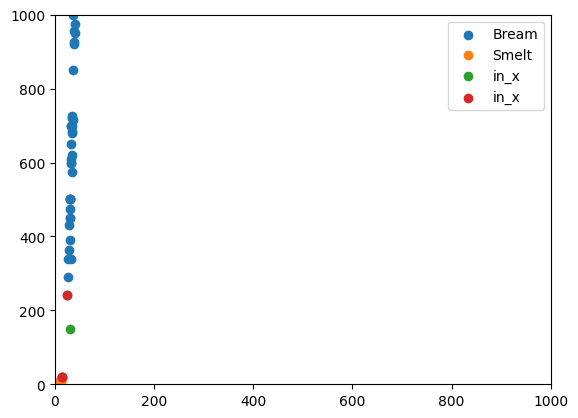

In [56]:
plt.xlim(0,1000)
plt.ylim(0,1000)
plt.scatter(new_X[:35,1],new_X[:35,0],label='Bream')
plt.scatter(new_X[35:,1],new_X[35:,0],label='Smelt')
plt.scatter(30,150,label='in_x')
plt.scatter(new_X[idx,1],new_X[idx,0],label='in_x')
plt.legend()
plt.show()

In [57]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
ms=MinMaxScaler()
ms.fit(new_X)
ss=StandardScaler()
ss.fit(new_X)

,copy,True
,with_mean,True
,with_std,True


In [58]:
ms_X=ms.transform(new_X)#0~1조정 (회귀)  이상치 민감
ss_X=ss.transform(new_X)#평균 0 분산 1값의 형태로 조정 (분류) 이상치 민감

In [61]:
np.unique(ms_X)

array([0.00000000e+00, 3.02023558e-04, 8.05396154e-04, 2.01349039e-03,
       3.02023558e-03, 3.12091010e-03, 3.22158462e-03, 3.32225914e-03,
       5.53709856e-03, 6.74519279e-03, 1.30876875e-02, 1.32890365e-02,
       2.24358974e-02, 2.56410256e-02, 3.84615385e-02, 4.48717949e-02,
       4.80769231e-02, 6.41025641e-02, 7.05128205e-02, 7.69230769e-02,
       8.33333333e-02, 1.02564103e-01, 1.44230769e-01, 1.66666667e-01,
       2.36887144e-01, 2.85210913e-01, 3.35548173e-01, 3.58703312e-01,
       3.85885432e-01, 4.26155240e-01, 4.46290144e-01, 4.71458774e-01,
       4.96627404e-01, 5.00000000e-01, 5.28846154e-01, 5.35256410e-01,
       5.72133293e-01, 5.97301923e-01, 6.07369375e-01, 6.15384615e-01,
       6.17436827e-01, 6.37820513e-01, 6.47435897e-01, 6.47639183e-01,
       6.69871795e-01, 6.77841538e-01, 6.79487179e-01, 6.82875264e-01,
       6.95512821e-01, 6.97976442e-01, 7.11538462e-01, 7.12070875e-01,
       7.18111346e-01, 7.23145072e-01, 7.43589744e-01, 7.59615385e-01,
      

In [62]:
np.unique(ss_X)

array([-1.70206487, -1.63301599, -1.62315187, -1.58369537, -1.56396712,
       -1.55410299, -1.50478237, -1.48505411, -1.46532586, -1.44559761,
       -1.38641286, -1.34799948, -1.34707578, -1.34553626, -1.34184142,
       -1.33876239, -1.33845449, -1.33814659, -1.33783868, -1.33106482,
       -1.32736998, -1.30797209, -1.30735628, -1.25817924, -1.18913036,
       -0.62350364, -0.47571019, -0.32175867, -0.25094097, -0.16780715,
       -0.16326134, -0.07448421, -0.05475596, -0.04464594,  0.01693467,
        0.09391043,  0.17088618,  0.19184717,  0.26089605,  0.29048842,
        0.3595373 ,  0.38912967,  0.40181346,  0.4384503 ,  0.47878922,
        0.48777093,  0.50957952,  0.54036983,  0.58641218,  0.63274074,
        0.6357328 ,  0.68505343,  0.72511165,  0.73437406,  0.7405068 ,
        0.78369468,  0.78669225,  0.82979868,  0.84827286,  0.86366801,
        0.88233593,  0.98097719,  1.12893906,  1.22758032,  1.2485468 ,
        1.37554219,  1.46407893,  1.47947408,  1.55644984,  1.57

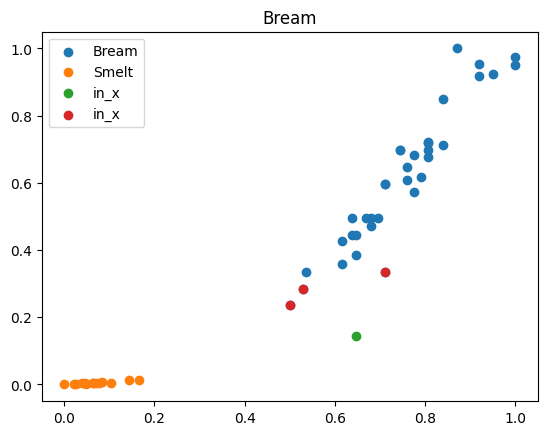

In [71]:
m1=KNeighborsClassifier(3).fit(ms_X,new_y)
in_data=[[150,30]]
ms_in_data=ms.transform(in_data)
d,idx=m1.kneighbors(ms_in_data)
py=m1.predict(ms_in_data)[0]
plt.scatter(ms_X[:35,1],ms_X[:35,0],label='Bream')
plt.scatter(ms_X[35:,1],ms_X[35:,0],label='Smelt')
plt.scatter(ms_in_data[0,1],ms_in_data[0,0],label='in_x')
plt.scatter(ms_X[idx,1],ms_X[idx,0],label='in_x')
plt.title(py)
plt.legend()
plt.show()

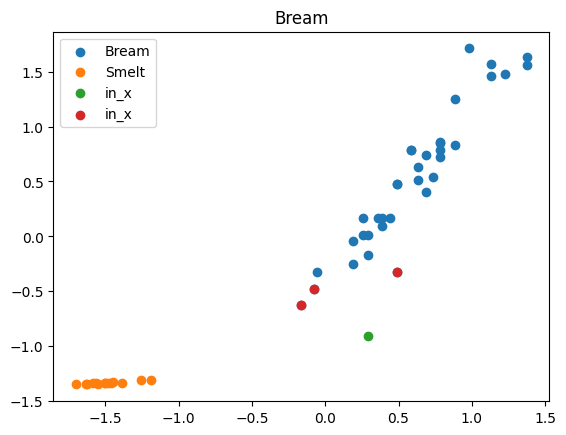

In [76]:
m2=KNeighborsClassifier(3).fit(ss_X,new_y)
in_data=[[150,30]]
ss_in_data=ss.transform(in_data)
d,idx=m2.kneighbors(ss_in_data)
py=m2.predict(ss_in_data)[0]
plt.scatter(ss_X[:35,1],ss_X[:35,0],label='Bream')
plt.scatter(ss_X[35:,1],ss_X[35:,0],label='Smelt')
plt.scatter(ss_in_data[0,1],ss_in_data[0,0],label='in_x')
plt.scatter(ss_X[idx,1],ss_X[idx,0],label='in_x')
plt.title(py)
plt.legend()
plt.show()

In [77]:
X=np.array([152,154,156,159,163,165,167,168,168,172,172,176,176,177,182,186,189,190])
y=np.array([46,47,49,58,56,57,59,64,62,69,68,71,75,75,83,90,97,100])

In [79]:
new_X=X.reshape(-1,1)

In [81]:
new_X.shape

(18, 1)

In [82]:
y.shape

(18,)

In [99]:
from sklearn.neighbors import KNeighborsRegressor
m=KNeighborsRegressor(1)
m.fit(new_X,y)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [105]:
m.predict([[1000]])

array([100.])

In [101]:
X

array([152, 154, 156, 159, 163, 165, 167, 168, 168, 172, 172, 176, 176,
       177, 182, 186, 189, 190])

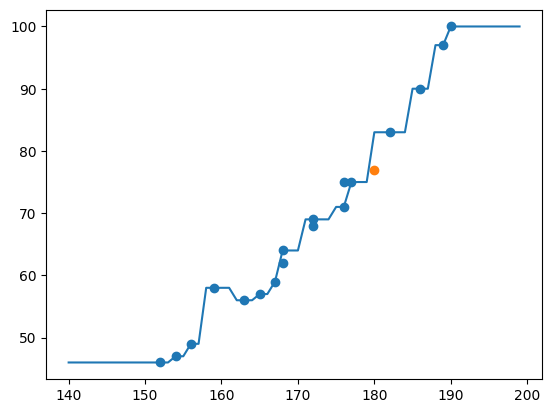

In [102]:
in_x=np.arange(140,200).reshape(-1,1)
py=m.predict(in_x)
plt.scatter(new_X,y)
plt.scatter(180,77)
plt.plot(in_x,py)